# Token-wise Linear Probe Localization for PanDerm GAP Model

This notebook computes a plot similar to **Figure D.4** from *Do Vision Transformers See Like Convolutional Neural Networks?*

Goal:
- freeze a fine-tuned PanDerm model,
- extract patch-token features from selected transformer blocks,
- train one linear probe per token location,
- evaluate each token probe on the test set,
- visualize token-wise classification accuracy as a 14×14 heatmap.

Interpretation:
- brighter token = this spatial token alone contains more class-discriminative information,
- this is **not CAM** and not attention,
- it shows where classification information is available in the model representation.

Recommended blocks for PanDerm Base:
- `-6`: middle block
- `-4`: your interesting block
- `-2`: late block
- `-1`: final block


## 0. What you need to set

Before running, check these paths:

- `REPO_ROOT`
- `CSV_PATH`
- `ROOT_PATH`
- `CHECKPOINT_PATH`
- `MODEL_NAME`
- `NB_CLASSES`
- `CLASS_NAMES`

This notebook assumes your model uses the PanDerm classification code from:

```text
external/PanDerm/classification/models/modeling_finetune.py
```

It also assumes your CSV has at least:

```text
image, label, split
```

where `split` contains `train`, `val`, and `test`.


In [ ]:

from pathlib import Path
import sys
import os
import random
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")

# -----------------------------
# EDIT THESE
# -----------------------------
REPO_ROOT = Path("..").resolve()
REPO_ROOT = REPO_ROOT / "master-thesis"
PANDERM_CLASSIFICATION_DIR = REPO_ROOT / "external" / "PanDerm" / "classification"

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "HAM10000.csv"
ROOT_PATH = REPO_ROOT / "data" / "HAM10000" / "images"

# Put your trained GAP checkpoint here.
# Example:
# CHECKPOINT_PATH = REPO_ROOT / "outputs" / "ham_base_nomix_weighted" / "checkpoint-best.pth"
CHECKPOINT_PATH = REPO_ROOT / "external" / "checkpoints3" / "checkpoint-best-HA075-cls.pth"

MODEL_NAME = "PanDerm_Base_FT"
NB_CLASSES = 7
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 4
SEED = 0

# Run all 12 PanDerm Base blocks.
# These resolve to block indices 0,1,2,...,11.
SELECTED_BLOCKS = list(range(12))

# Use more samples if runtime is okay.
# For the final version, I would use all test samples.
MAX_TRAIN_SAMPLES = 1000
MAX_TEST_SAMPLES = None

PROBE_TYPE = "sgd"

# CLS model
USE_MEAN_POOLING = False
POOLING_NAME = "CLS token pooling"

OUT_DIR = REPO_ROOT / "outputs" / "token_probe_cls_all_blocks"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

print("REPO_ROOT:", REPO_ROOT)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("ROOT exists:", ROOT_PATH.exists(), ROOT_PATH)
print("CHECKPOINT exists:", CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)
print("OUT_DIR:", OUT_DIR)


REPO_ROOT: /storage/homefs/cn21m021/projects/master-thesis
CSV exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/HAM10000.csv
ROOT exists: True /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/images
CHECKPOINT exists: True /storage/homefs/cn21m021/projects/master-thesis/external/checkpoints3/checkpoint-best-HA075-cls.pth
OUT_DIR: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks


In [2]:

def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)


DEVICE: cuda


## 1. Dataset and transforms

This uses simple evaluation transforms. For linear probing, we usually do **not** use heavy train augmentation, because we want stable feature extraction.


In [3]:

class CSVDermDataset(Dataset):
    def __init__(self, df, root_path, transform=None, image_col="image", label_col="label"):
        self.df = df.reset_index(drop=True)
        self.root_path = Path(root_path)
        self.transform = transform
        self.image_col = image_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root_path / str(row[self.image_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = int(row[self.label_col])
        return img, label, str(row[self.image_col])

# PanDerm training command used imagenet_default_mean_and_std in your baseline.
# If your run used different normalization, change this accordingly.
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

df = pd.read_csv(CSV_PATH, low_memory=False)
print("CSV shape:", df.shape)
print("Columns:", list(df.columns))

split = df["split"].astype(str).str.lower()
train_df = df[split == "train"].copy()
val_df = df[split == "val"].copy()
test_df = df[split == "test"].copy()

# Optionally combine train + val for probe training.
probe_train_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

if MAX_TRAIN_SAMPLES is not None and len(probe_train_df) > MAX_TRAIN_SAMPLES:
    probe_train_df = probe_train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

print("Probe train:", probe_train_df.shape)
print("Test:", test_df.shape)
print("Train label counts:\n", probe_train_df["label"].value_counts().sort_index())
print("Test label counts:\n", test_df["label"].value_counts().sort_index())

train_ds = CSVDermDataset(probe_train_df, ROOT_PATH, transform=eval_transform)
test_ds = CSVDermDataset(test_df, ROOT_PATH, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


CSV shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']
Probe train: (1000, 13)
Test: (1232, 13)
Train label counts:
 label
0     33
1     50
2    118
3     19
4    117
5    652
6     11
Name: count, dtype: int64
Test label counts:
 label
0     35
1     44
2    107
3      8
4     70
5    951
6     17
Name: count, dtype: int64


## 2. Load PanDerm model

Important:
- `use_mean_pooling=True` means GAP-style mean pooling over patch tokens.
- `use_mean_pooling=False` means CLS-token pooling.

For your current GAP model, keep `use_mean_pooling=True`.


In [4]:

from models.modeling_finetune import panderm_base_patch16_224_finetune, panderm_large_patch16_224_finetune


def build_model():
    common_kwargs = dict(
        pretrained=False,
        num_classes=NB_CLASSES,
        drop_rate=0.0,
        drop_path_rate=0.0,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=USE_MEAN_POOLING,   # GAP-style pooling. Change only for a CLS-trained checkpoint.
        init_scale=0.001,
        use_rel_pos_bias=False,
        init_values=0.1,
        lin_probe=False,         # full fine-tuning mode
    )
    if MODEL_NAME == "PanDerm_Base_FT":
        return panderm_base_patch16_224_finetune(**common_kwargs)
    elif MODEL_NAME == "PanDerm_Large_FT":
        return panderm_large_patch16_224_finetune(**common_kwargs)
    else:
        raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")


def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["model", "state_dict", "module"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                ckpt = ckpt[key]
                break
    new_sd = OrderedDict()
    for k, v in ckpt.items():
        if k.startswith("module."):
            k = k[len("module."):]
        new_sd[k] = v
    return new_sd

model = build_model()
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
sd = unwrap_state_dict(ckpt)

missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
if len(missing) < 20:
    print("Missing:", missing)
if len(unexpected) < 20:
    print("Unexpected:", unexpected)

model.to(DEVICE)
model.eval()
for p in model.parameters():
    p.requires_grad = False

print("Number of transformer blocks:", len(model.blocks))
print("Patch grid:", model.patch_embed.patch_shape)
print("Num patches:", model.patch_embed.num_patches)
print("use_mean_pooling:", model.use_mean_pooling)


Missing keys: 0
Unexpected keys: 0
Missing: []
Unexpected: []
Number of transformer blocks: 12
Patch grid: (14, 14)
Num patches: 196
use_mean_pooling: False


## 3. Feature extraction from selected blocks

We register forward hooks on transformer blocks.

For a 12-block PanDerm Base:
- `-1` = block 11 = final/highest block
- `-4` = block 8 = late-middle/high-ish block

The hook stores the patch tokens after the chosen block.


In [5]:

def normalize_block_indices(selected_blocks, num_blocks):
    out = []
    for b in selected_blocks:
        idx = b if b >= 0 else num_blocks + b
        if idx < 0 or idx >= num_blocks:
            raise ValueError(f"Block {b} resolves to {idx}, outside 0..{num_blocks-1}")
        out.append(idx)
    return out

BLOCK_INDICES = normalize_block_indices(SELECTED_BLOCKS, len(model.blocks))
# BLOCK_LABELS = [f"block {b} (idx {idx})" for b, idx in zip(SELECTED_BLOCKS, BLOCK_INDICES)]
BLOCK_LABELS = [f"block {idx}" for idx in BLOCK_INDICES]
print(list(zip(SELECTED_BLOCKS, BLOCK_INDICES)))

@torch.no_grad()
def extract_features_for_blocks(model, loader, block_indices):
    storage = {idx: [] for idx in block_indices}
    labels = []
    image_names = []
    hooks = []

    def make_hook(idx):
        def hook(module, inputs, output):
            # output shape: [B, 1 + num_patches, C]
            patch_tokens = output[:, 1:, :].detach().cpu().float()
            storage[idx].append(patch_tokens)
        return hook

    for idx in block_indices:
        hooks.append(model.blocks[idx].register_forward_hook(make_hook(idx)))

    try:
        for batch_idx, (images, y, names) in enumerate(loader):
            images = images.to(DEVICE, non_blocking=True)
            _ = model(images)
            labels.append(y.cpu())
            image_names.extend(list(names))
            if (batch_idx + 1) % 20 == 0:
                print(f"Processed {batch_idx + 1}/{len(loader)} batches")
    finally:
        for h in hooks:
            h.remove()

    features = {idx: torch.cat(storage[idx], dim=0).numpy() for idx in block_indices}
    labels = torch.cat(labels, dim=0).numpy()
    return features, labels, image_names

print("Extracting TRAIN features...")
train_features, y_train, train_names = extract_features_for_blocks(model, train_loader, BLOCK_INDICES)
print("Extracting TEST features...")
test_features, y_test, test_names = extract_features_for_blocks(model, test_loader, BLOCK_INDICES)

for idx in BLOCK_INDICES:
    print(idx, "train", train_features[idx].shape, "test", test_features[idx].shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11)]
Extracting TRAIN features...
Extracting TEST features...
Processed 20/20 batches
0 train (1000, 196, 768) test (1232, 196, 768)
1 train (1000, 196, 768) test (1232, 196, 768)
2 train (1000, 196, 768) test (1232, 196, 768)
3 train (1000, 196, 768) test (1232, 196, 768)
4 train (1000, 196, 768) test (1232, 196, 768)
5 train (1000, 196, 768) test (1232, 196, 768)
6 train (1000, 196, 768) test (1232, 196, 768)
7 train (1000, 196, 768) test (1232, 196, 768)
8 train (1000, 196, 768) test (1232, 196, 768)
9 train (1000, 196, 768) test (1232, 196, 768)
10 train (1000, 196, 768) test (1232, 196, 768)
11 train (1000, 196, 768) test (1232, 196, 768)
y_train: (1000,) y_test: (1232,)


## 4. Train one linear probe per token location

This can take some time because for a 14×14 patch grid we train 196 small classifiers per selected block.

For speed:
- start with `PROBE_TYPE = "sgd"`,
- optionally set `MAX_TRAIN_SAMPLES = 2000` while debugging.


In [6]:

def make_probe():
    if PROBE_TYPE == "logreg":
        # More standard but slower.
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                multi_class="auto",
                solver="lbfgs",
                n_jobs=-1,
            ),
        )
    elif PROBE_TYPE == "sgd":
        # Faster approximate linear classifier.
        return make_pipeline(
            StandardScaler(),
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=1e-4,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=SEED,
            ),
        )
    else:
        raise ValueError(PROBE_TYPE)


def compute_token_probe_map(X_train, y_train, X_test, y_test, grid_shape):
    # X_* shape: [N, T, C]
    n_tokens = X_train.shape[1]
    accs = []
    bal_accs = []

    for t in range(n_tokens):
        clf = make_probe()
        clf.fit(X_train[:, t, :], y_train)
        pred = clf.predict(X_test[:, t, :])
        accs.append(accuracy_score(y_test, pred))
        bal_accs.append(balanced_accuracy_score(y_test, pred))

        if (t + 1) % 25 == 0:
            print(f"  token {t + 1}/{n_tokens}")

    acc_map = np.array(accs).reshape(grid_shape)
    bal_acc_map = np.array(bal_accs).reshape(grid_shape)
    return acc_map, bal_acc_map

results = {}
grid_shape = model.patch_embed.patch_shape

for selected, idx in zip(SELECTED_BLOCKS, BLOCK_INDICES):
    print(f"\nTraining token probes for block {selected} / index {idx}")
    acc_map, bal_acc_map = compute_token_probe_map(
        train_features[idx], y_train,
        test_features[idx], y_test,
        grid_shape=grid_shape,
    )
    results[selected] = {
        "idx": idx,
        "accuracy": acc_map,
        "balanced_accuracy": bal_acc_map,
    }

    np.save(OUT_DIR / f"token_probe_accuracy_block_{selected}.npy", acc_map)
    np.save(OUT_DIR / f"token_probe_balanced_accuracy_block_{selected}.npy", bal_acc_map)

print("Done.")



Training token probes for block 0 / index 0
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 1 / index 1
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 2 / index 2
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 3 / index 3
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 4 / index 4
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 5 / index 5
  token 25/196
  token 50/196
  token 75/196
  token 100/196
  token 125/196
  token 150/196
  token 175/196

Training token probes for block 6 / index 6
  token 25/196
  token 50/196
 

## 5. Plot heatmaps

Important interpretation rule:

- If each subplot has its own color scale, compare locations **within** a block.
- If all subplots share one color scale, compare absolute values **across** blocks.

Both views are useful.


In [7]:
def plot_maps(results, metric="balanced_accuracy", shared_scale=False, title_suffix=""):
    blocks = list(results.keys())
    maps = [results[b][metric] for b in blocks]

    if shared_scale:
        vmin = min(m.min() for m in maps)
        vmax = max(m.max() for m in maps)
    else:
        vmin = vmax = None

    n_blocks = len(blocks)
    n_cols = 4
    n_rows = int(np.ceil(n_blocks / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 4.2 * n_rows),
        constrained_layout=True,
    )
    axes = np.array(axes).reshape(-1)

    for ax, b, m in zip(axes, blocks, maps):
        center_value = m[m.shape[0] // 2, m.shape[1] // 2]
        im = ax.imshow(m, vmin=vmin, vmax=vmax)

        ax.set_title(
            f"Block {results[b]['idx']}\n"
            f"mean={m.mean():.3f}, max={m.max():.3f}, center={center_value:.3f}",
            fontsize=10,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[len(blocks):]:
        ax.axis("off")

    fig.suptitle(
        f"{POOLING_NAME} | token-wise linear probe {metric} {title_suffix}",
        fontsize=15,
    )
    return fig

print("Saved plots to:", OUT_DIR)


Saved plots to: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks


- test accuracy or test balanced accuracy of the probe trained on that token position
- class information map over token locations.
- If I use only the center patch token from this block for every image, how accurately can I classify the image?

In [13]:
def build_block_summary(results):
    rows = []

    for b, d in results.items():
        resolved_idx = d["idx"]

        for metric in ["accuracy", "balanced_accuracy"]:
            m = d[metric]
            center_value = float(m[m.shape[0] // 2, m.shape[1] // 2])

            rows.append({
                "pooling": POOLING_NAME,
                "block": b,
                "resolved_index": resolved_idx,
                "metric": metric,
                "mean": float(m.mean()),
                "std": float(m.std()),
                "min": float(m.min()),
                "max": float(m.max()),
                "center_value": center_value,
                "spatial_contrast": float(m.max() - m.mean()),
            })

    return pd.DataFrame(rows)


summary_df = build_block_summary(results)
summary_path = OUT_DIR / "token_probe_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Saved:", summary_path)
print("Columns:", list(summary_df.columns))

,pooling,block,resolved_index,metric,mean,std,min,max,center_value,spatial_contrast
0,CLS token pooling,0,0,accuracy,0.739518,0.013105,0.702922,0.776786,0.763799,0.037267
1,CLS token pooling,0,0,balanced_accuracy,0.236865,0.032164,0.186207,0.359909,0.309535,0.123044
2,CLS token pooling,1,1,accuracy,0.754245,0.011782,0.724838,0.797890,0.782468,0.043645
3,CLS token pooling,1,1,balanced_accuracy,0.222743,0.026207,0.179790,0.317465,0.266052,0.094723
4,CLS token pooling,2,2,accuracy,0.769203,0.009909,0.748377,0.800325,0.784903,0.031122
5,CLS token pooling,2,2,balanced_accuracy,0.223152,0.026110,0.185441,0.332669,0.294557,0.109517
6,CLS token pooling,3,3,accuracy,0.770230,0.011446,0.745942,0.816558,0.799513,0.046328
7,CLS token pooling,3,3,balanced_accuracy,0.226861,0.028534,0.183200,0.369043,0.323085,0.142181
8,CLS token pooling,4,4,accuracy,0.777394,0.012251,0.751623,0.819805,0.812500,0.042411
9,CLS token pooling,4,4,balanced_accuracy,0.239446,0.033992,0.189015,0.369988,0.357377,0.130542


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_summary.csv
Columns: ['pooling', 'block', 'resolved_index', 'metric', 'mean', 'std', 'min', 'max', 'center_value', 'spatial_contrast']


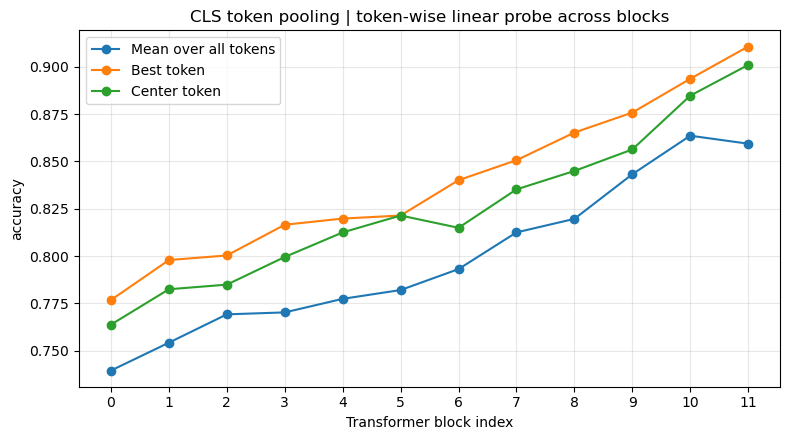

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_curve_accuracy.png


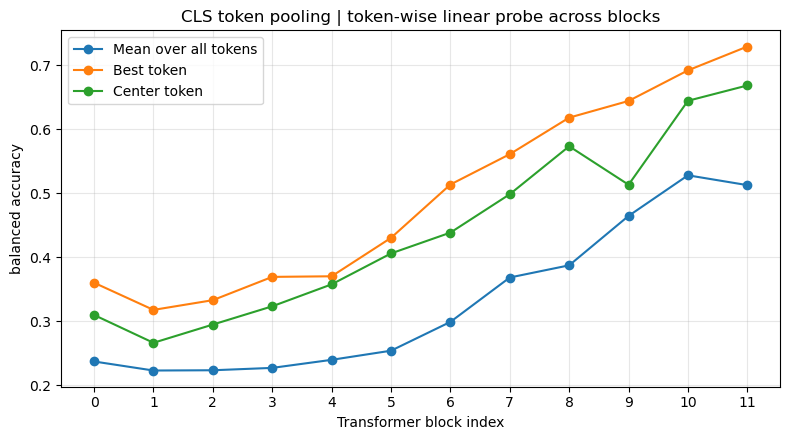

Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_curve_balanced_accuracy.png


In [14]:
def plot_block_curves(summary_df, metric="balanced_accuracy"):
    sub = summary_df[summary_df["metric"] == metric].copy()
    sub = sub.sort_values("resolved_index")

    plt.figure(figsize=(8, 4.5))
    plt.plot(sub["resolved_index"], sub["mean"], marker="o", label="Mean over all tokens")
    plt.plot(sub["resolved_index"], sub["max"], marker="o", label="Best token")
    plt.plot(sub["resolved_index"], sub["center_value"], marker="o", label="Center token")

    plt.xlabel("Transformer block index")
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"{POOLING_NAME} | token-wise linear probe across blocks")
    plt.xticks(sub["resolved_index"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = OUT_DIR / f"token_probe_curve_{metric}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


plot_block_curves(summary_df, metric="accuracy")
plot_block_curves(summary_df, metric="balanced_accuracy")

In [15]:
best_blocks = (
    summary_df
    .sort_values(["metric", "mean"], ascending=[True, False])
    .groupby("metric")
    .head(5)
    .reset_index(drop=True)
)

display(best_blocks)
best_blocks.to_csv(OUT_DIR / "token_probe_best_blocks.csv", index=False)

,pooling,block,resolved_index,metric,mean,std,min,max,center_value,spatial_contrast
0,CLS token pooling,10,10,accuracy,0.863599,0.010987,0.844156,0.893669,0.884740,0.030070
1,CLS token pooling,11,11,accuracy,0.859379,0.018013,0.801948,0.910714,0.900974,0.051335
2,CLS token pooling,9,9,accuracy,0.843224,0.011582,0.820617,0.875812,0.856331,0.032588
3,CLS token pooling,8,8,accuracy,0.819652,0.017713,0.780032,0.865260,0.844968,0.045608
4,CLS token pooling,7,7,accuracy,0.812508,0.014313,0.784903,0.850649,0.835227,0.038141
5,CLS token pooling,10,10,balanced_accuracy,0.527750,0.048696,0.432074,0.691730,0.644178,0.163979
6,CLS token pooling,11,11,balanced_accuracy,0.512409,0.076008,0.369985,0.728954,0.668134,0.216545
7,CLS token pooling,9,9,balanced_accuracy,0.464306,0.052256,0.350957,0.643919,0.513022,0.179613
8,CLS token pooling,8,8,balanced_accuracy,0.387117,0.074364,0.271071,0.617843,0.573120,0.230725
9,CLS token pooling,7,7,balanced_accuracy,0.368078,0.061356,0.262911,0.560778,0.498206,0.192700


Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_all_blocks_cls_balanced_accuracy.pdf


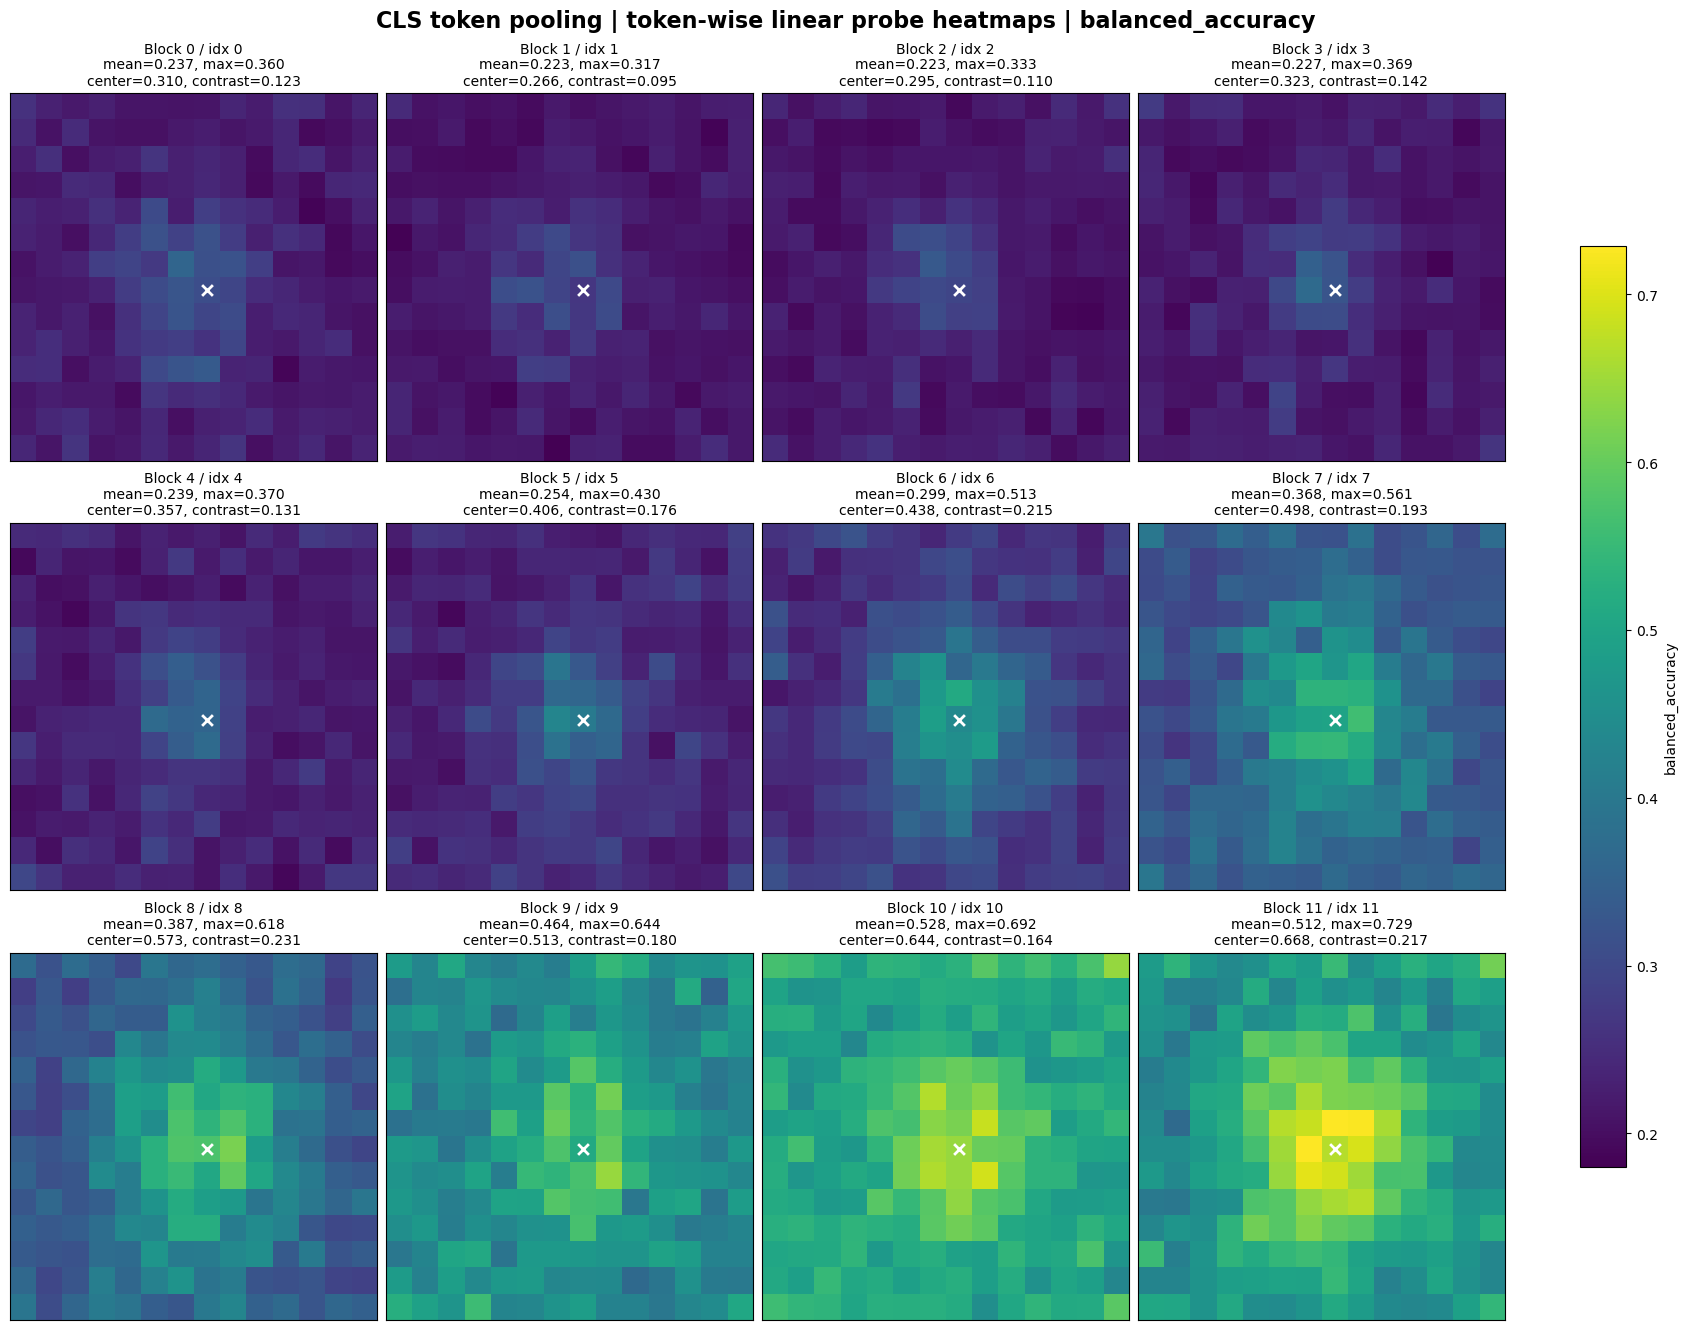

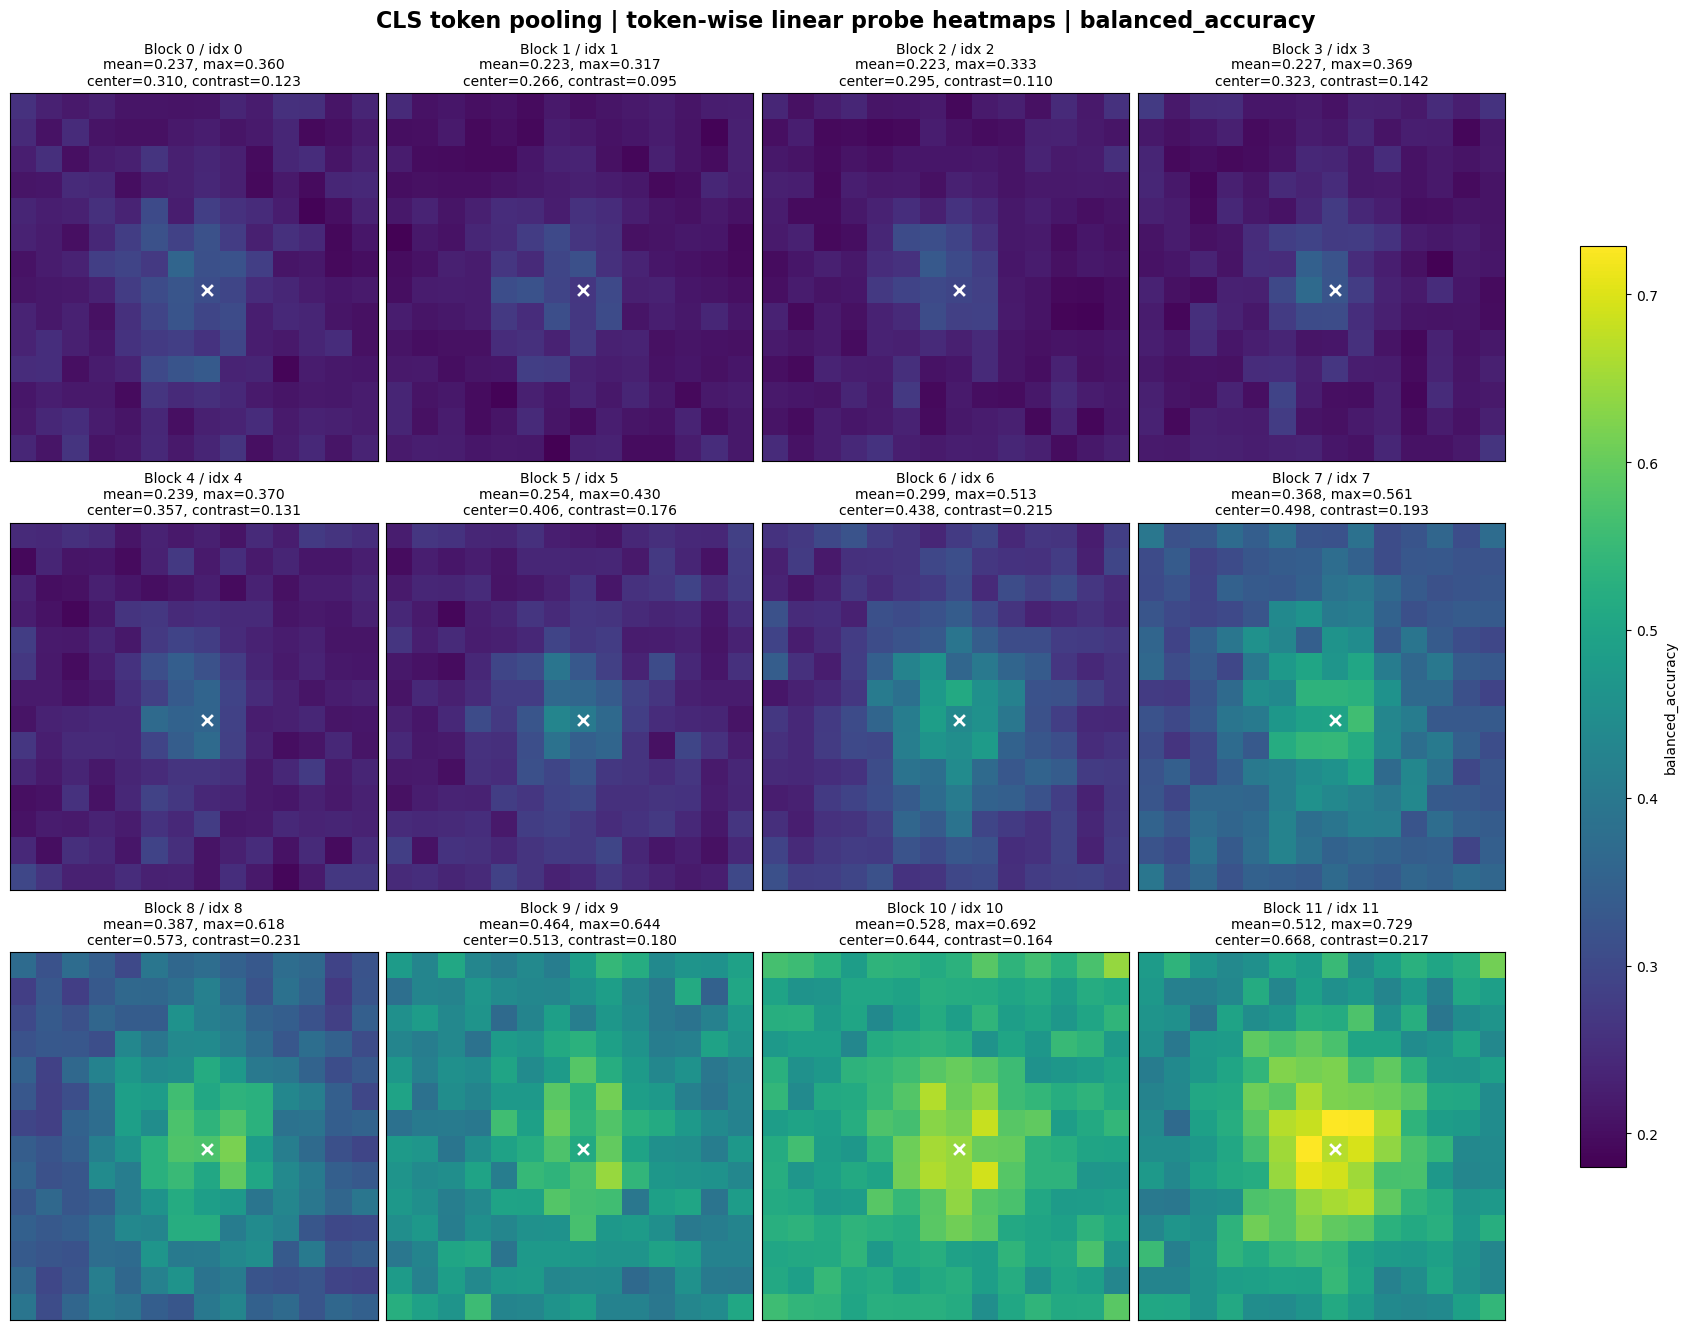

In [16]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import numpy as np

def get_metric_value(summary_df, block, metric, column):
    row = summary_df[
        (summary_df["block"] == block) &
        (summary_df["metric"] == metric)
    ]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][column])


def plot_all_block_heatmaps_to_pdf(
    results,
    summary_df,
    metric="balanced_accuracy",
    pooling_name="GAP / mean pooling",
    out_pdf=None,
    shared_scale=True,
    ncols=4,
):
    """
    Creates one PDF page with all block heatmaps.

    metric:
        "accuracy" or "balanced_accuracy"

    shared_scale:
        True = same color scale across all blocks.
        This is better for comparing blocks.
    """

    blocks = list(results.keys())
    maps = [results[b][metric] for b in blocks]

    if shared_scale:
        vmin = min(m.min() for m in maps)
        vmax = max(m.max() for m in maps)
    else:
        vmin = vmax = None

    n_blocks = len(blocks)
    nrows = int(np.ceil(n_blocks / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.4 * nrows),
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    last_im = None

    for ax, b, m in zip(axes, blocks, maps):
        resolved_idx = results[b]["idx"]

        mean_val = get_metric_value(summary_df, b, metric, "mean")
        max_val = get_metric_value(summary_df, b, metric, "max")
        center_val = get_metric_value(summary_df, b, metric, "center_value")
        spatial_contrast = get_metric_value(summary_df, b, metric, "spatial_contrast")

        last_im = ax.imshow(m, vmin=vmin, vmax=vmax)

        ax.set_title(
            f"Block {b} / idx {resolved_idx}\n"
            f"mean={mean_val:.3f}, max={max_val:.3f}\n"
            f"center={center_val:.3f}, contrast={spatial_contrast:.3f}",
            fontsize=10,
        )

        ax.set_xticks([])
        ax.set_yticks([])

        # Mark center token approximately
        h, w = m.shape
        ax.scatter(
            [w // 2],
            [h // 2],
            marker="x",
            s=60,
            linewidths=2,
            c="white",
        )

    for ax in axes[len(blocks):]:
        ax.axis("off")

    fig.suptitle(
        f"{pooling_name} | token-wise linear probe heatmaps | {metric}",
        fontsize=16,
        fontweight="bold",
    )

    if shared_scale and last_im is not None:
        fig.colorbar(
            last_im,
            ax=axes[:len(blocks)].tolist(),
            shrink=0.75,
            label=metric,
        )

    if out_pdf is not None:
        with PdfPages(out_pdf) as pdf:
            pdf.savefig(fig)
        print("Saved PDF:", out_pdf)

    plt.show()
    return fig


POOLING_NAME = "GAP / mean pooling" if USE_MEAN_POOLING else "CLS token pooling"

pdf_path_bal = OUT_DIR / f"token_probe_all_blocks_{'gap' if USE_MEAN_POOLING else 'cls'}_balanced_accuracy.pdf"

plot_all_block_heatmaps_to_pdf(
    results=results,
    summary_df=summary_df,
    metric="balanced_accuracy",
    pooling_name=POOLING_NAME,
    out_pdf=pdf_path_bal,
    shared_scale=True,
    ncols=4,
)

Saved PDF: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_all_blocks_cls_accuracy.pdf


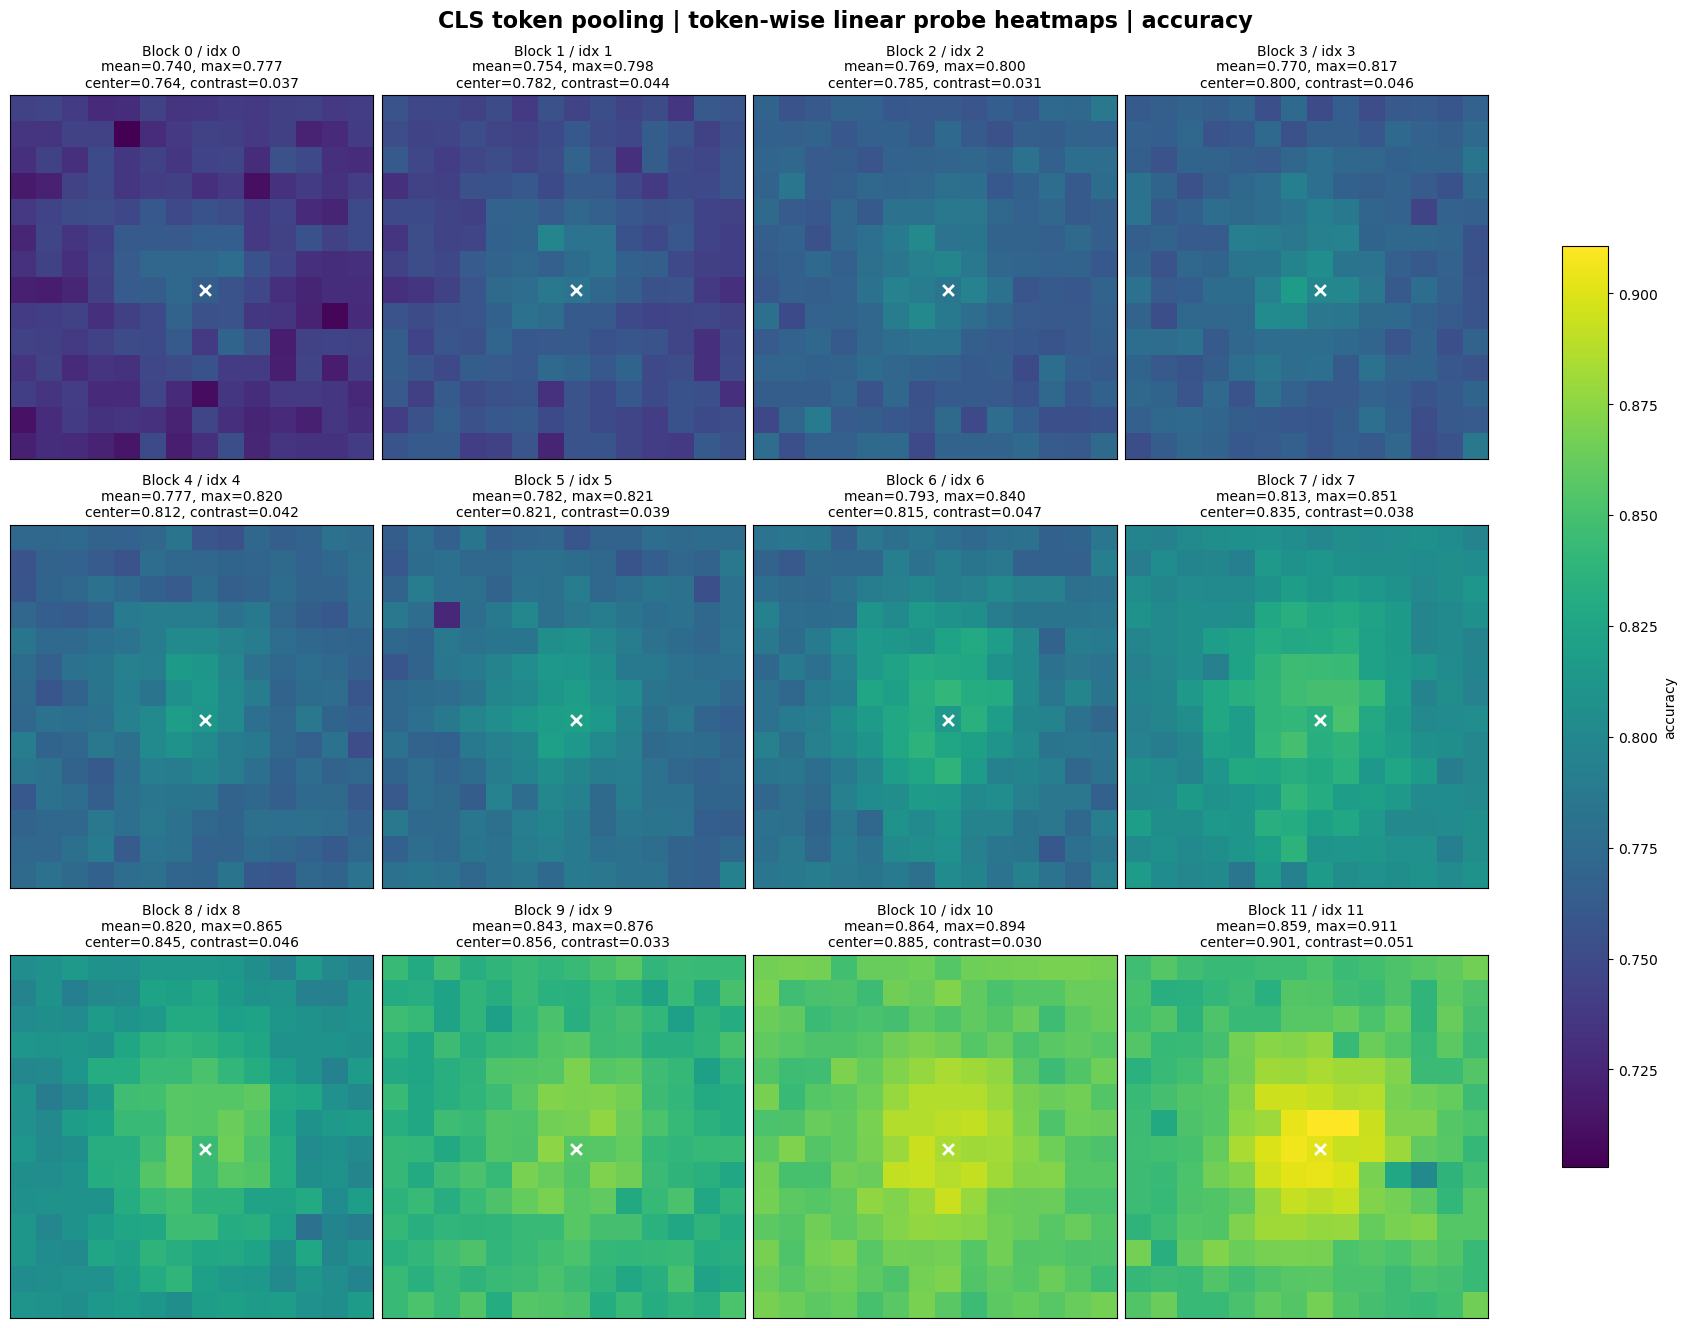

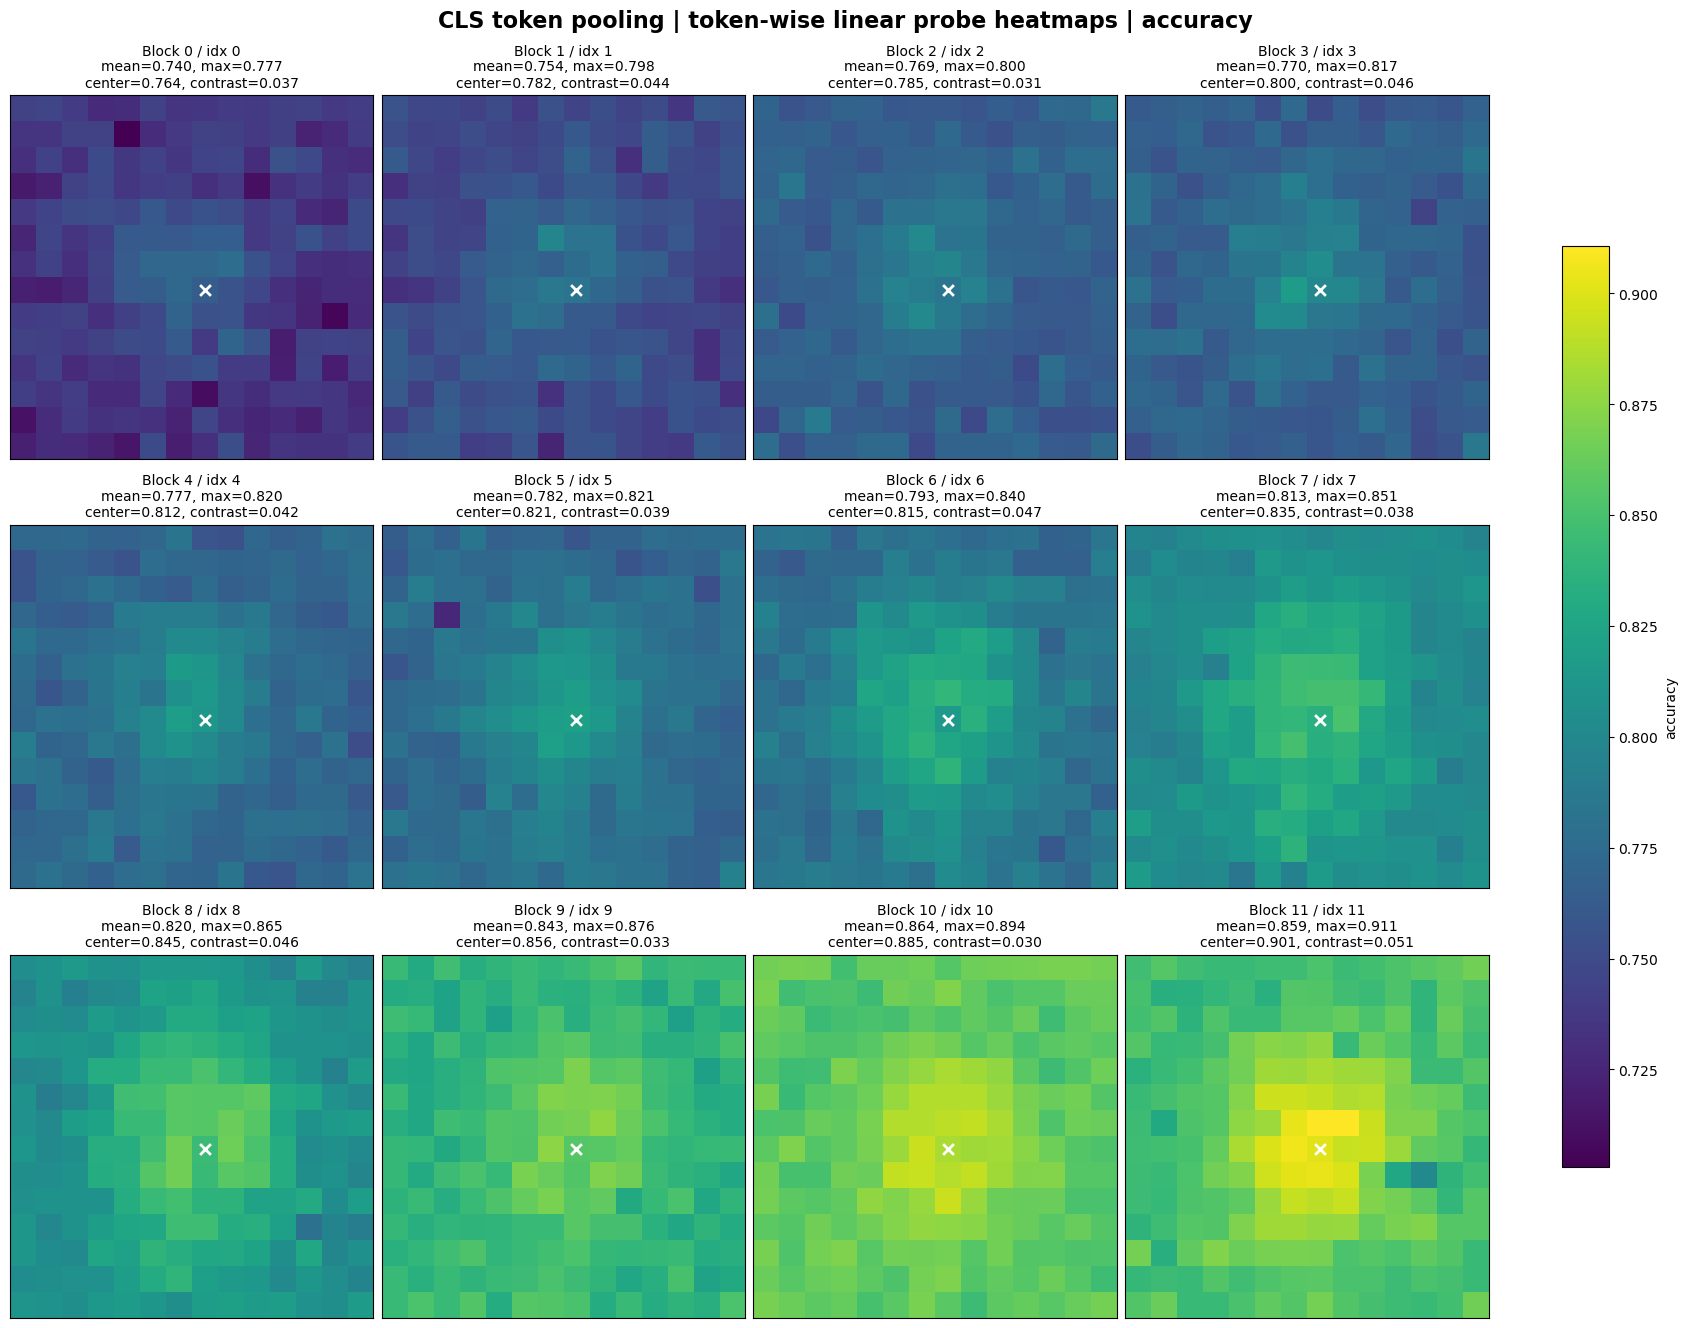

: 

In [ ]:
pdf_path_acc = OUT_DIR / f"token_probe_all_blocks_{'gap' if USE_MEAN_POOLING else 'cls'}_accuracy.pdf"

plot_all_block_heatmaps_to_pdf(
    results=results,
    summary_df=summary_df,
    metric="accuracy",
    pooling_name=POOLING_NAME,
    out_pdf=pdf_path_acc,
    shared_scale=True,
    ncols=4,
)

## 6. Save summary table

This table helps you compare blocks numerically.


In [11]:

summary_rows = []
for b, d in results.items():
    for metric in ["accuracy", "balanced_accuracy"]:
        m = d[metric]
        summary_rows.append({
            "block": b,
            "resolved_index": d["idx"],
            "metric": metric,
            "mean": float(m.mean()),
            "std": float(m.std()),
            "min": float(m.min()),
            "max": float(m.max()),
            "center_value": float(m[m.shape[0] // 2, m.shape[1] // 2]),
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "token_probe_summary.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Saved:", summary_path)


,block,resolved_index,metric,mean,std,min,max,center_value
0,0,0,accuracy,0.739518,0.013105,0.702922,0.776786,0.763799
1,0,0,balanced_accuracy,0.236865,0.032164,0.186207,0.359909,0.309535
2,1,1,accuracy,0.754245,0.011782,0.724838,0.797890,0.782468
3,1,1,balanced_accuracy,0.222743,0.026207,0.179790,0.317465,0.266052
4,2,2,accuracy,0.769203,0.009909,0.748377,0.800325,0.784903
5,2,2,balanced_accuracy,0.223152,0.026110,0.185441,0.332669,0.294557
6,3,3,accuracy,0.770230,0.011446,0.745942,0.816558,0.799513
7,3,3,balanced_accuracy,0.226861,0.028534,0.183200,0.369043,0.323085
8,4,4,accuracy,0.777394,0.012251,0.751623,0.819805,0.812500
9,4,4,balanced_accuracy,0.239446,0.033992,0.189015,0.369988,0.357377


Saved: /storage/homefs/cn21m021/projects/master-thesis/outputs/token_probe_cls_all_blocks/token_probe_summary.csv


## 7. How to interpret your result

Use this logic:

### If final block `-1` is very uniformly high
This means final patch tokens are all similarly class-informative.
That is expected for a GAP model, because the classifier averages patch tokens.

Thesis wording:

> The final GAP representation distributes class information broadly across spatial tokens, which may reduce spatial specificity for CAM generation.

### If block `-4` is more spatially concentrated
This supports your observation that block `-4` can produce better CAMs.

Thesis wording:

> Block −4 appears to provide a better trade-off between semantic class information and spatial specificity.

### If the center is strongest
Be careful. HAM10000 lesions are often centered.

Thesis wording:

> The center-dominant pattern may reflect lesion-centered dataset bias and should not be interpreted as direct evidence of perfect lesion localization.

### If balanced accuracy is more informative than accuracy
HAM10000 is highly imbalanced. Accuracy can be dominated by the NV class.
Use balanced accuracy as your main metric if the class imbalance is strong.


## 8. Optional next step

After this notebook, compare these token-probe maps with your CAM localization results.

Recommended thesis figure:

1. Token-probe map for block `-4` and block `-1`
2. CAM map for block `-4` and block `-1`
3. Quantitative mask alignment or perturbation score for both blocks

This would directly support the claim that the final GAP layer is more global, while block `-4` is more useful for spatial explanation.
